In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
df = pd.read_csv(r'D:\Machine Learning\placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
data = df.iloc[:,1:]

In [5]:
data.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [6]:
import matplotlib.pyplot as plt

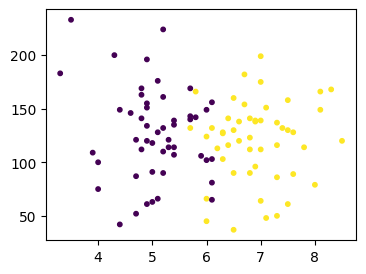

In [7]:
plt.figure(figsize=(4,3))
plt.scatter(data['cgpa'],data['iq'],c=data['placement'],s=10)

In [8]:
x = data.iloc[:,0:2]
y = data.iloc[:,2]

In [9]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [10]:
from sklearn.model_selection import train_test_split

x_train,x_text,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [11]:
x_train

,cgpa,iq
69,8.5,120.0
63,6.3,128.0
31,3.9,109.0
40,4.9,134.0
46,5.3,114.0
...,...,...
19,5.2,132.0
72,7.3,116.0
65,8.1,166.0
41,5.4,114.0


In [12]:
y_train

69    1
63    1
31    0
40    0
46    0
     ..
19    0
72    1
65    1
41    0
95    0
Name: placement, Length: 90, dtype: int64

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
x_train = scaler.fit_transform(x_train)

In [16]:
x_train

array([[ 2.22112109, -0.08526339],
       [ 0.29225277,  0.11024502],
       [-1.8119672 , -0.35408745],
       [-0.93520888,  0.25687632],
       [-0.58450555, -0.23189469],
       [-0.75985721,  1.28329547],
       [ 0.37992861, -0.18301759],
       [-0.49682972, -0.40296455],
       [-1.02288471, -0.2807718 ],
       [-2.3380222 ,  1.45436532],
       [-0.67218138,  0.9167172 ],
       [-0.23380222,  0.47682328],
       [-2.16267053,  2.67629287],
       [ 1.1690111 ,  0.33019198],
       [-0.75985721, -1.40494514],
       [ 0.11690111,  0.20799922],
       [ 0.11690111,  0.79452445],
       [-0.67218138, -0.3296489 ],
       [ 0.81830777,  0.37906908],
       [ 0.81830777,  0.35463053],
       [ 0.99365943, -1.84483906],
       [ 0.46760444, -0.81841992],
       [ 0.73063194, -0.01194774],
       [-0.93520888, -1.5271379 ],
       [-1.11056054, -0.89173557],
       [-1.02288471,  0.9655943 ],
       [ 0.37992861,  0.42794618],
       [ 0.9059836 ,  1.25885691],
       [-0.67218138,

In [17]:
x_text = scaler.transform(x_text)

In [18]:
x_text

array([[-0.23380222,  0.20799922],
       [ 1.87041776,  0.62345459],
       [-0.67218138, -0.81841992],
       [ 0.46760444,  0.15912212],
       [ 1.60739026, -0.23189469],
       [-0.93520888,  0.67233169],
       [-0.93520888, -0.08526339],
       [ 0.11690111, -1.42938369],
       [ 0.99365943,  0.67233169],
       [-0.14612639,  0.45238473]])

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
l = LogisticRegression()

In [21]:
l.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
y_pred = l.predict(x_text)

In [23]:
y_test

87    1
37    1
28    0
57    1
55    1
89    0
22    0
56    0
21    1
4     0
Name: placement, dtype: int64

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
accuracy_score(y_pred,y_test)

0.8

In [26]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

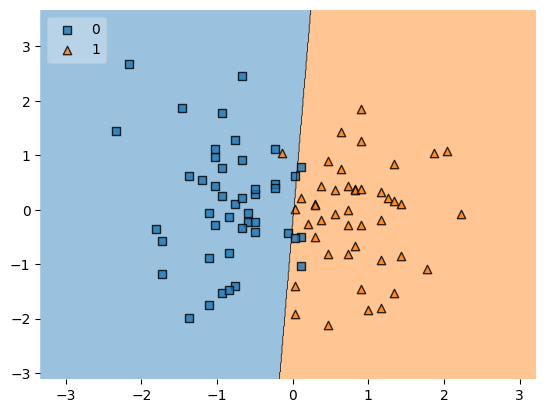

In [27]:
plot_decision_regions(x_train, y_train.values, clf=l, legend=2)

In [28]:
import pickle

In [29]:
pickle.dump(l,open('model.pkl','wb'))